# Chapter 9 Python Lab  
## Linear Approximation, Tangent Planes, and Differentials

This lab accompanies **Chapter 9: Linear Approximation, Tangent Planes, and Differentials**.

The central idea is that a differentiable multivariable function is locally almost linear. Near a point $(a,b)$,

$$
f(x,y)\approx f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b).
$$

The right-hand side is the **linearization** of $f$ at $(a,b)$ and gives the **tangent plane** to the surface $z=f(x,y)$.

This lab uses Python to explore:

- tangent planes to graphs $z=f(x,y)$;
- local linear approximations;
- error surfaces and error scaling;
- differentials $df=f_x\,dx+f_y\,dy$;
- tangent planes to level surfaces $F(x,y,z)=c$;
- measurement error propagation;
- local models in data and optimization.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. compute linearizations of functions of two variables;
2. visualize a surface and its tangent plane;
3. compare a nonlinear function with its local linear approximation;
4. study approximation error as distance from the base point increases;
5. use differentials to estimate small changes in function values;
6. compute tangent planes to level surfaces using gradients;
7. distinguish graph tangent planes from level-surface tangent planes;
8. estimate error propagation from measurement uncertainty;
9. interpret linearization as a local model;
10. connect tangent planes with optimization and machine learning loss landscapes.

## Source note

This notebook was generated from the uploaded Chapter 9 QMD file.  
The extracted early headings from the source file include:

- Chapter overview
- Learning goals
- 9.1 Review: tangent lines and local linearity
- 9.2 Tangent planes to graphs $z=f(x,y)$
- Why this is the right plane
- 9.3 Worked example: tangent plane to an elliptic paraboloid
- Example 9.1
- Solution
- 9.4 Linear approximation in gradient form
- Example 9.2
- Solution
- 9.5 Approximation error and curvature

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)

def make_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=160):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def make_3d_axes(title=None, elev=28, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def finite_diff_x(f, x, y, h=1e-5):
    return (f(x + h, y) - f(x - h, y)) / (2*h)

def finite_diff_y(f, x, y, h=1e-5):
    return (f(x, y + h) - f(x, y - h)) / (2*h)

def finite_gradient(f, x, y, h=1e-5):
    return np.array([finite_diff_x(f, x, y, h), finite_diff_y(f, x, y, h)], dtype=float)

def linearization(f, fx, fy, a, b):
    f0 = f(a, b)
    fx0 = fx(a, b)
    fy0 = fy(a, b)
    def L(X, Y):
        return f0 + fx0*(X - a) + fy0*(Y - b)
    return L

def numerical_linearization(f, a, b, h=1e-5):
    f0 = f(a, b)
    fx0 = finite_diff_x(f, a, b, h=h)
    fy0 = finite_diff_y(f, a, b, h=h)
    def L(X, Y):
        return f0 + fx0*(X - a) + fy0*(Y - b)
    return L, fx0, fy0

def plot_surface_and_plane(f, L, a, b, xmin, xmax, ymin, ymax, n=100,
                           title="Surface and tangent plane", zlim=None,
                           elev=28, azim=45):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n)
    Z = safe_eval_2d(f, X, Y)
    P = safe_eval_2d(L, X, Y)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, alpha=0.55, linewidth=0)
    ax.plot_surface(X, Y, P, alpha=0.35, linewidth=0)
    ax.scatter([a], [b], [f(a,b)], s=80)
    if zlim is not None:
        ax.set_zlim(*zlim)
    plt.show()
    return X, Y, Z, P

def plot_surface_only(f, xmin, xmax, ymin, ymax, n=120, title="Surface", zlim=None, elev=28, azim=45):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n)
    Z = safe_eval_2d(f, X, Y)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.85)
    if zlim is not None:
        ax.set_zlim(*zlim)
    plt.show()
    return X, Y, Z

def norm(v):
    return np.linalg.norm(v)

def unit(v, tol=1e-12):
    v = np.asarray(v, dtype=float)
    n = norm(v)
    if n < tol:
        raise ValueError("The zero vector has no unit direction.")
    return v / n

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-3vxhtil4 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Linearization of a function of two variables

For a differentiable function $f(x,y)$, the linearization at $(a,b)$ is

$$
L(x,y)=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b).
$$

This is the best affine approximation to $f$ near $(a,b)$.

The tangent plane to the graph $z=f(x,y)$ at $(a,b,f(a,b))$ is

$$
z=L(x,y).
$$

## 1. First example: a quadratic surface

Let

$$
f(x,y)=x^2+xy+2y^2.
$$

Then

$$
f_x(x,y)=2x+y,\qquad f_y(x,y)=x+4y.
$$

At $(a,b)=(1,-1)$,

$$
f(1,-1)=2,\qquad f_x(1,-1)=1,\qquad f_y(1,-1)=-3.
$$

In [2]:
def f_quad(X, Y):
    return X**2 + X*Y + 2*Y**2

def fx_quad(X, Y):
    return 2*X + Y

def fy_quad(X, Y):
    return X + 4*Y

a, b = 1.0, -1.0
L_quad = linearization(f_quad, fx_quad, fy_quad, a, b)

print("Base point (a,b):", (a, b))
print("f(a,b):", f_quad(a, b))
print("f_x(a,b):", fx_quad(a, b))
print("f_y(a,b):", fy_quad(a, b))
print("L(1.05,-1.02):", L_quad(1.05, -1.02))
print("f(1.05,-1.02):", f_quad(1.05, -1.02))

Base point (a,b): (1.0, -1.0)
f(a,b): 2.0
f_x(a,b): 1.0
f_y(a,b): -3.0
L(1.05,-1.02): 2.11
f(1.05,-1.02): 2.1123


## 2. Surface and tangent plane

The surface and tangent plane touch at the base point. Near the base point they are close; farther away the curvature becomes visible.

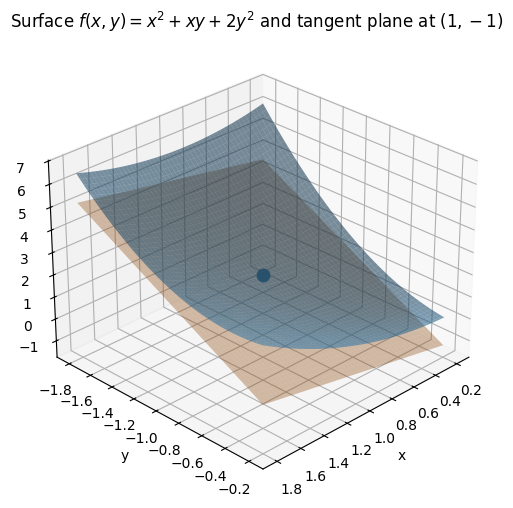

(array([[0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        ...,
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ]],
       shape=(100, 100)),
 array([[-1.8     , -1.8     , -1.8     , ..., -1.8     , -1.8     ,
         -1.8     ],
        [-1.783838, -1.783838, -1.783838, ..., -1.783838, -1.783838,
         -1.783838],
        [-1.767677, -1.767677, -1.767677, ..., -1.767677, -1.767677,
         -1.767677],
        ...,
        [-0.232323, -0.232323, -0.232323, ..., -0.232323, -0.232323,
         -0.232323],
        [-0.216162, -0.216162, -0.216162, ..., -0.216162, -0.216162,
         -0.216162],
        [-0.2     , -0.2     , -0.2     , ..., 

In [3]:
plot_surface_and_plane(
    f_quad, L_quad, a, b,
    xmin=0.2, xmax=1.8, ymin=-1.8, ymax=-0.2,
    title=r"Surface $f(x,y)=x^2+xy+2y^2$ and tangent plane at $(1,-1)$",
    elev=28,
    azim=45
)

## 3. Approximation table

We compare $f(x,y)$ with $L(x,y)$ at several nearby points.

In [4]:
test_points = [
    (1.01, -1.02),
    (1.05, -0.95),
    (1.10, -0.90),
    (1.25, -0.75),
    (1.50, -0.50),
]

print(f"{'point':>18s} {'f(x,y)':>12s} {'L(x,y)':>12s} {'error L-f':>12s}")
for x0, y0 in test_points:
    true_val = f_quad(x0, y0)
    approx_val = L_quad(x0, y0)
    print(f"{str((x0,y0)):>18s} {true_val:12.6f} {approx_val:12.6f} {approx_val-true_val:12.6f}")

             point       f(x,y)       L(x,y)    error L-f
     (1.01, -1.02)     2.070700     2.070000    -0.000700
     (1.05, -0.95)     1.910000     1.900000    -0.010000
       (1.1, -0.9)     1.840000     1.800000    -0.040000
     (1.25, -0.75)     1.750000     1.500000    -0.250000
       (1.5, -0.5)     2.000000     1.000000    -1.000000


## 4. Error surface and error heatmap

The approximation error is

$$
E(x,y)=f(x,y)-L(x,y).
$$

For a tangent-plane approximation, this error should be very small near the base point.

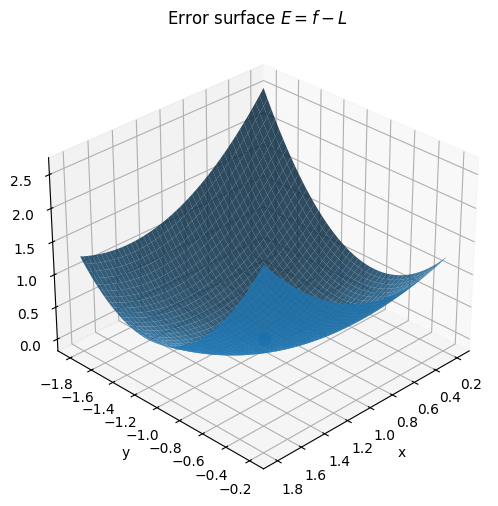

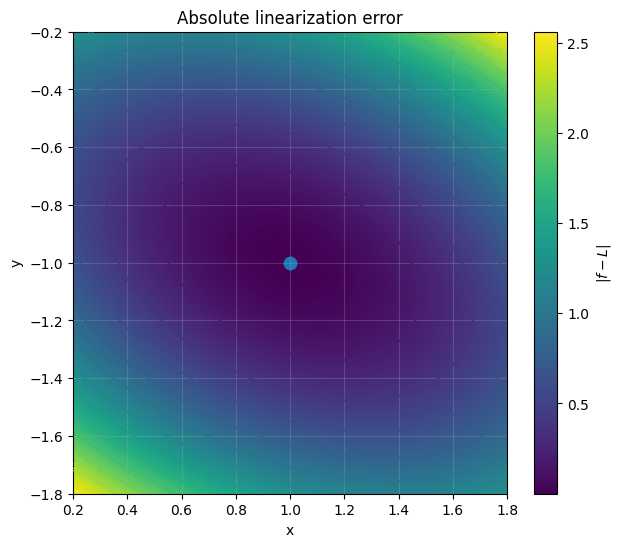

Maximum absolute error on this window: 2.560000000000001


In [5]:
def error_quad(X, Y):
    return f_quad(X, Y) - L_quad(X, Y)

x, y, X, Y = make_grid(0.2, 1.8, -1.8, -0.2, n=180)
E = error_quad(X, Y)

fig, ax = make_3d_axes(title=r"Error surface $E=f-L$", elev=30, azim=45)
ax.plot_surface(X, Y, E, linewidth=0, alpha=0.85)
ax.scatter([a], [b], [0], s=80)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(np.abs(E), extent=[0.2, 1.8, -1.8, -0.2], origin="lower", aspect="auto")
cs = ax.contour(X, Y, np.abs(E), levels=12)
ax.clabel(cs, inline=True, fontsize=8)
ax.scatter([a], [b], s=80)
fig.colorbar(im, ax=ax, label=r"$|f-L|$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Absolute linearization error")
ax.grid(True, alpha=0.25)
plt.show()

print("Maximum absolute error on this window:", np.max(np.abs(E)))

## 5. Error versus distance from the base point

Let

$$
r=\sqrt{(x-a)^2+(y-b)^2}.
$$

We sample points on circles of radius $r$ centered at $(a,b)$ and compute the maximum error on each circle.

radius= 0.020, max |error|=0.00088284
radius= 0.040, max |error|=0.00353137
radius= 0.080, max |error|=0.01412548
radius= 0.160, max |error|=0.05650193
radius= 0.320, max |error|=0.22600773
radius= 0.640, max |error|=0.90403094


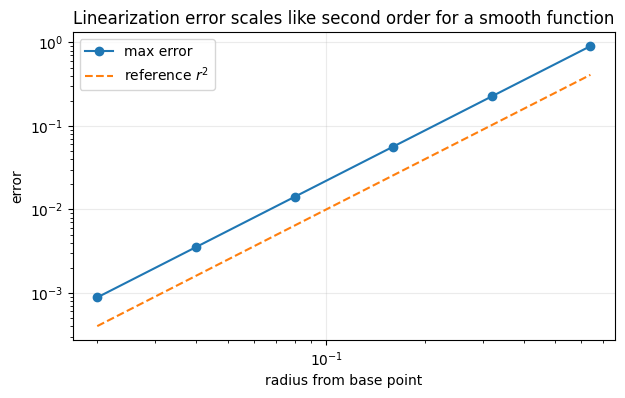

In [6]:
def max_error_on_circle(f, L, a, b, radii, ntheta=720):
    theta = np.linspace(0, 2*np.pi, ntheta, endpoint=False)
    max_errors = []
    mean_errors = []
    for r in radii:
        X = a + r*np.cos(theta)
        Y = b + r*np.sin(theta)
        E = safe_eval_2d(f, X, Y) - safe_eval_2d(L, X, Y)
        max_errors.append(np.max(np.abs(E)))
        mean_errors.append(np.mean(np.abs(E)))
    return np.array(max_errors), np.array(mean_errors)

radii = np.array([0.02, 0.04, 0.08, 0.16, 0.32, 0.64])
max_err, mean_err = max_error_on_circle(f_quad, L_quad, a, b, radii)

for r, me in zip(radii, max_err):
    print(f"radius={r: .3f}, max |error|={me:.8f}")

plt.figure(figsize=(7, 4))
plt.loglog(radii, max_err, marker="o", label="max error")
plt.loglog(radii, radii**2, linestyle="--", label=r"reference $r^2$")
plt.xlabel("radius from base point")
plt.ylabel("error")
plt.title("Linearization error scales like second order for a smooth function")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part II. Linearization from numerical partial derivatives

In applications we may not know $f_x$ and $f_y$ symbolically. Finite differences can estimate them:

$$
f_x(a,b)\approx\frac{f(a+h,b)-f(a-h,b)}{2h},
\qquad
f_y(a,b)\approx\frac{f(a,b+h)-f(a,b-h)}{2h}.
$$

## 6. Numerical linearization

In [7]:
L_num, fx_num, fy_num = numerical_linearization(f_quad, a, b)

print("Numerical f_x:", fx_num)
print("Exact f_x:", fx_quad(a, b))
print("Numerical f_y:", fy_num)
print("Exact f_y:", fy_quad(a, b))
print("Numerical L(1.05,-1.02):", L_num(1.05, -1.02))
print("Exact-symbolic L(1.05,-1.02):", L_quad(1.05, -1.02))

Numerical f_x: 1.0000000000065512
Exact f_x: 1.0
Numerical f_y: -2.9999999999974487
Exact f_y: -3.0
Numerical L(1.05,-1.02): 2.1100000000002765
Exact-symbolic L(1.05,-1.02): 2.11


## 7. Step-size sensitivity

Finite-difference derivatives depend on the step size $h$.

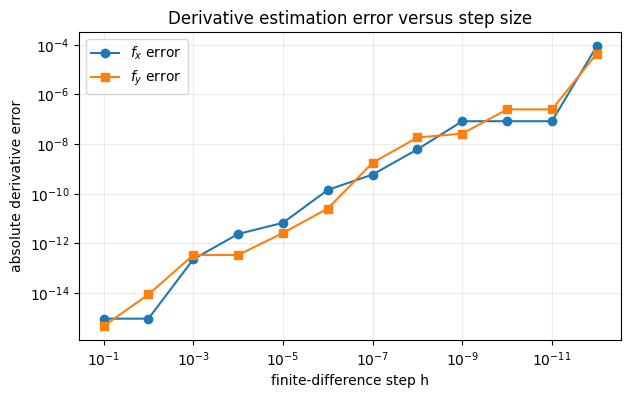

In [8]:
h_values = 10.0**(-np.arange(1, 13))
fx_errors = []
fy_errors = []

for h in h_values:
    _, fx_h, fy_h = numerical_linearization(f_quad, a, b, h=h)
    fx_errors.append(abs(fx_h - fx_quad(a, b)))
    fy_errors.append(abs(fy_h - fy_quad(a, b)))

plt.figure(figsize=(7, 4))
plt.loglog(h_values, fx_errors, marker="o", label=r"$f_x$ error")
plt.loglog(h_values, fy_errors, marker="s", label=r"$f_y$ error")
plt.gca().invert_xaxis()
plt.xlabel("finite-difference step h")
plt.ylabel("absolute derivative error")
plt.title("Derivative estimation error versus step size")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part III. Tangent planes to nonlinear surfaces

Consider

$$
f(x,y)=e^{-x^2-y^2}.
$$

This is a smooth hill with peak at the origin. The partial derivatives are

$$
f_x=-2xe^{-x^2-y^2},\qquad
f_y=-2ye^{-x^2-y^2}.
$$

## 8. Gaussian hill and tangent plane

We linearize at $(a,b)=(1,0.5)$.

In [9]:
def f_gaussian(X, Y):
    return np.exp(-X**2 - Y**2)

def fx_gaussian(X, Y):
    return -2*X*np.exp(-X**2 - Y**2)

def fy_gaussian(X, Y):
    return -2*Y*np.exp(-X**2 - Y**2)

a_g, b_g = 1.0, 0.5
L_gaussian = linearization(f_gaussian, fx_gaussian, fy_gaussian, a_g, b_g)

print("Base point:", (a_g, b_g))
print("f(a,b):", f_gaussian(a_g, b_g))
print("f_x(a,b):", fx_gaussian(a_g, b_g))
print("f_y(a,b):", fy_gaussian(a_g, b_g))

Base point: (1.0, 0.5)
f(a,b): 0.2865047968601901
f_x(a,b): -0.5730095937203802
f_y(a,b): -0.2865047968601901


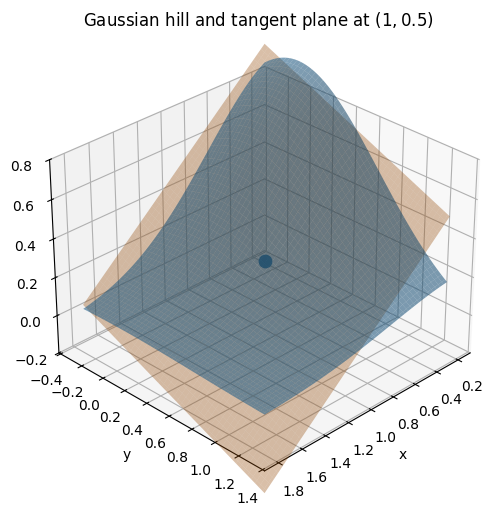

(array([[0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        ...,
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ],
        [0.2     , 0.216162, 0.232323, ..., 1.767677, 1.783838, 1.8     ]],
       shape=(100, 100)),
 array([[-0.3     , -0.3     , -0.3     , ..., -0.3     , -0.3     ,
         -0.3     ],
        [-0.283838, -0.283838, -0.283838, ..., -0.283838, -0.283838,
         -0.283838],
        [-0.267677, -0.267677, -0.267677, ..., -0.267677, -0.267677,
         -0.267677],
        ...,
        [ 1.267677,  1.267677,  1.267677, ...,  1.267677,  1.267677,
          1.267677],
        [ 1.283838,  1.283838,  1.283838, ...,  1.283838,  1.283838,
          1.283838],
        [ 1.3     ,  1.3     ,  1.3     , ..., 

In [10]:
plot_surface_and_plane(
    f_gaussian, L_gaussian, a_g, b_g,
    xmin=0.2, xmax=1.8, ymin=-0.3, ymax=1.3,
    title=r"Gaussian hill and tangent plane at $(1,0.5)$",
    zlim=(-0.2, 0.8),
    elev=30,
    azim=45
)

## 9. Local zoom comparison

The tangent plane looks better when we zoom in near the base point.

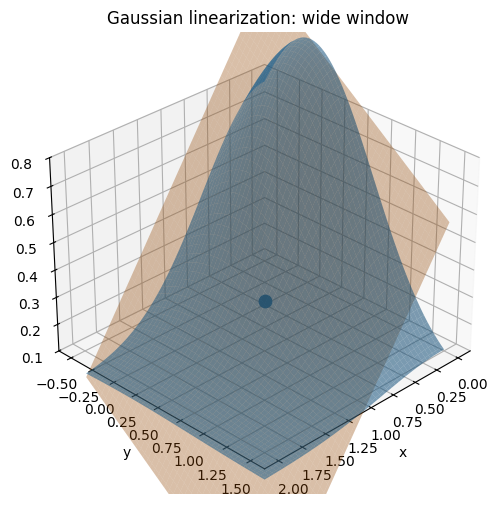

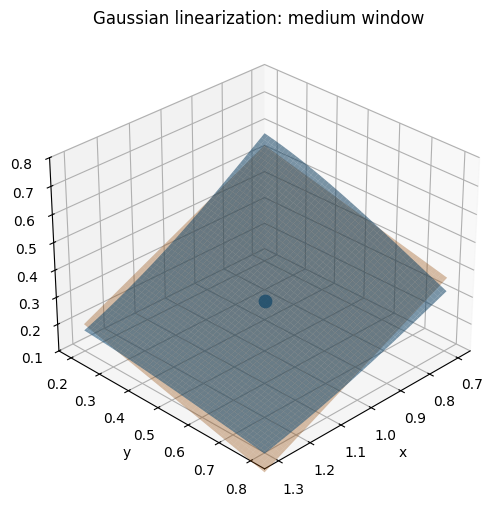

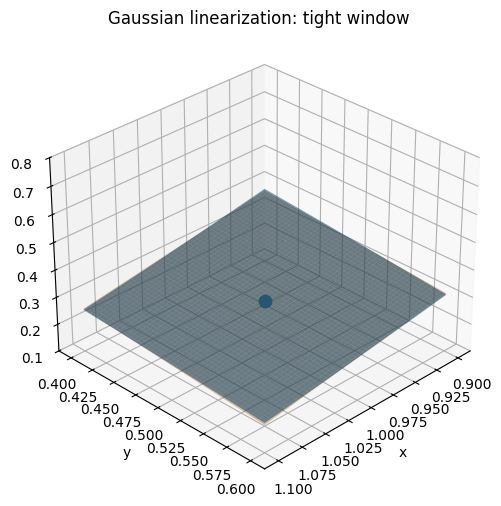

In [11]:
windows = [
    (0.0, 2.0, -0.5, 1.5, "wide window"),
    (0.7, 1.3, 0.2, 0.8, "medium window"),
    (0.9, 1.1, 0.4, 0.6, "tight window"),
]

for xmin, xmax, ymin, ymax, label in windows:
    plot_surface_and_plane(
        f_gaussian, L_gaussian, a_g, b_g,
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
        title=f"Gaussian linearization: {label}",
        zlim=(0.1, 0.8),
        elev=30,
        azim=45
    )

## 10. Linear approximation error for the Gaussian

radius= 0.020, max |error|=0.00017271
radius= 0.040, max |error|=0.00069375
radius= 0.080, max |error|=0.00279414
radius= 0.160, max |error|=0.01126849
radius= 0.320, max |error|=0.04494704


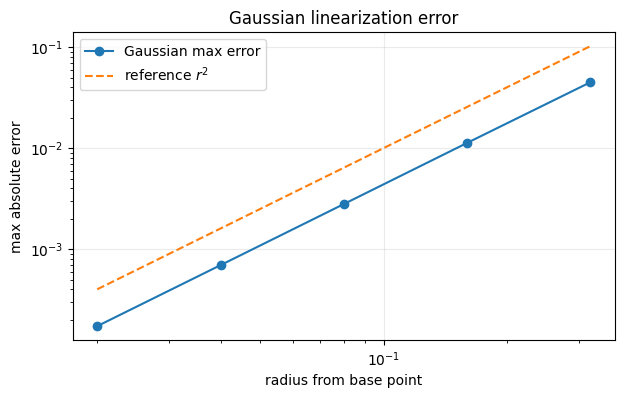

In [12]:
radii = np.array([0.02, 0.04, 0.08, 0.16, 0.32])
max_err, mean_err = max_error_on_circle(f_gaussian, L_gaussian, a_g, b_g, radii)

for r, me in zip(radii, max_err):
    print(f"radius={r: .3f}, max |error|={me:.8f}")

plt.figure(figsize=(7, 4))
plt.loglog(radii, max_err, marker="o", label="Gaussian max error")
plt.loglog(radii, radii**2, linestyle="--", label=r"reference $r^2$")
plt.xlabel("radius from base point")
plt.ylabel("max absolute error")
plt.title("Gaussian linearization error")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IV. Differentials

If $z=f(x,y)$, the differential is

$$
dz=df=f_x(a,b)\,dx+f_y(a,b)\,dy.
$$

It estimates the actual change

$$
\Delta z=f(a+dx,b+dy)-f(a,b).
$$

Thus

$$
\Delta z\approx dz.
$$

## 11. Differential approximation table

Use the Gaussian hill at $(1,0.5)$.

In [13]:
def differential(fx, fy, a, b, dx, dy):
    return fx(a, b)*dx + fy(a, b)*dy

increments = [
    (0.01, -0.02),
    (0.05, 0.04),
    (-0.08, 0.03),
    (0.15, -0.10),
    (0.30, 0.20),
]

print(f"{'dx':>8s} {'dy':>8s} {'Delta z':>14s} {'dz':>14s} {'error dz-Delta':>16s}")
for dx, dy in increments:
    delta_z = f_gaussian(a_g + dx, b_g + dy) - f_gaussian(a_g, b_g)
    dz = differential(fx_gaussian, fy_gaussian, a_g, b_g, dx, dy)
    print(f"{dx:8.3f} {dy:8.3f} {delta_z:14.8f} {dz:14.8f} {dz-delta_z:16.8f}")

      dx       dy        Delta z             dz   error dz-Delta
   0.010   -0.020    -0.00014322     0.00000000       0.00014322
   0.050    0.040    -0.03844861    -0.04011067      -0.00166206
  -0.080    0.030     0.03740183     0.03724562      -0.00015620
   0.150   -0.100    -0.05943549    -0.05730096       0.00213453
   0.300    0.200    -0.17346327    -0.22920384      -0.05574057


## 12. Differential as a dot product

The differential can be written as

$$
df=\nabla f(a,b)\cdot \langle dx,dy\rangle.
$$

In [14]:
grad_g = np.array([fx_gaussian(a_g, b_g), fy_gaussian(a_g, b_g)])
print("Gradient at base point:", grad_g)

dx, dy = 0.05, 0.04
d_input = np.array([dx, dy])
df_dot = np.dot(grad_g, d_input)
df_formula = differential(fx_gaussian, fy_gaussian, a_g, b_g, dx, dy)

print("Input change:", d_input)
print("df by dot product:", df_dot)
print("df by formula:", df_formula)

Gradient at base point: [-0.57301  -0.286505]
Input change: [0.05 0.04]
df by dot product: -0.040110671560426615
df by formula: -0.040110671560426615


## 13. Direction and size of small input changes

For a fixed size $r=\sqrt{dx^2+dy^2}$, the differential is largest in the gradient direction.

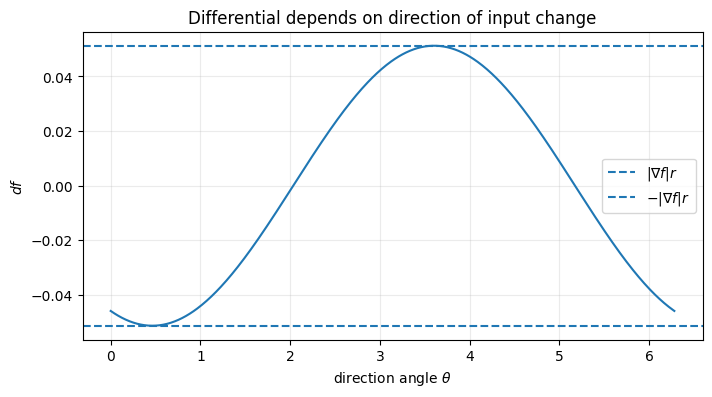

Maximum observed df: 0.05125128455510666
Theoretical maximum: 0.05125153613273227


In [15]:
r = 0.08
theta = np.linspace(0, 2*np.pi, 600)
dx = r*np.cos(theta)
dy = r*np.sin(theta)

df_values = fx_gaussian(a_g, b_g)*dx + fy_gaussian(a_g, b_g)*dy
max_possible = norm(grad_g)*r

plt.figure(figsize=(8, 4))
plt.plot(theta, df_values)
plt.axhline(max_possible, linestyle="--", label=r"$|\nabla f|r$")
plt.axhline(-max_possible, linestyle="--", label=r"$-|\nabla f|r$")
plt.xlabel(r"direction angle $\theta$")
plt.ylabel(r"$df$")
plt.title("Differential depends on direction of input change")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Maximum observed df:", np.max(df_values))
print("Theoretical maximum:", max_possible)

---

# Part V. Measurement error propagation

Differentials are often used to estimate how uncertainty in measurements affects a computed quantity.

If $z=f(x,y)$ and the measurement errors satisfy

$$
|dx|\le \epsilon_x,\qquad |dy|\le \epsilon_y,
$$

then a common worst-case estimate is

$$
|dz|\le |f_x(a,b)|\epsilon_x+|f_y(a,b)|\epsilon_y.
$$

## 14. Area of a rectangle

Suppose

$$
A=xy
$$

is the area of a rectangle with measured side lengths $x$ and $y$.

Then

$$
dA=y\,dx+x\,dy.
$$

Let $x=10$, $y=4$, with measurement errors $|dx|\le0.05$ and $|dy|\le0.02$.

In [16]:
def area_rect(X, Y):
    return X*Y

def area_x(X, Y):
    return Y

def area_y(X, Y):
    return X

x0, y0 = 10.0, 4.0
eps_x, eps_y = 0.05, 0.02

worst_case_dA = abs(area_x(x0, y0))*eps_x + abs(area_y(x0, y0))*eps_y

print("Measured area:", area_rect(x0, y0))
print("Worst-case differential error estimate:", worst_case_dA)
print("Relative error estimate:", worst_case_dA / area_rect(x0, y0))

Measured area: 40.0
Worst-case differential error estimate: 0.4
Relative error estimate: 0.01


## 15. Monte Carlo check for area error

We randomly sample measurement errors in the allowed range and compare the true area change to the differential approximation.

Maximum observed |true area change|: 0.39855166777987705
Worst-case differential estimate: 0.4
Maximum observed |dA approximation error|: 0.0009977482267166105


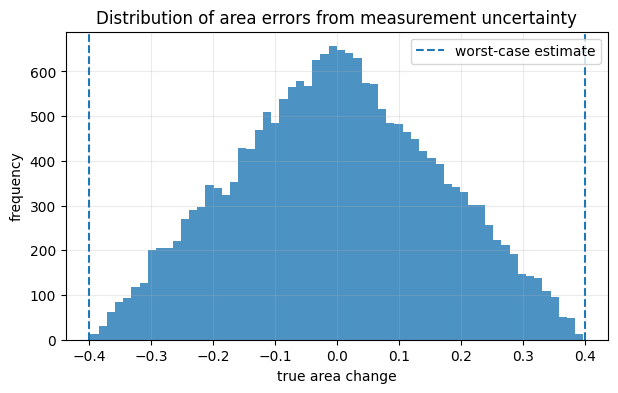

In [17]:
rng = np.random.default_rng(9)

n_samples = 20000
dx_samples = rng.uniform(-eps_x, eps_x, n_samples)
dy_samples = rng.uniform(-eps_y, eps_y, n_samples)

true_delta_A = area_rect(x0 + dx_samples, y0 + dy_samples) - area_rect(x0, y0)
dA_approx = area_x(x0, y0)*dx_samples + area_y(x0, y0)*dy_samples

print("Maximum observed |true area change|:", np.max(np.abs(true_delta_A)))
print("Worst-case differential estimate:", worst_case_dA)
print("Maximum observed |dA approximation error|:", np.max(np.abs(dA_approx - true_delta_A)))

plt.figure(figsize=(7, 4))
plt.hist(true_delta_A, bins=60, alpha=0.8)
plt.axvline(worst_case_dA, linestyle="--", label="worst-case estimate")
plt.axvline(-worst_case_dA, linestyle="--")
plt.xlabel("true area change")
plt.ylabel("frequency")
plt.title("Distribution of area errors from measurement uncertainty")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 16. Volume of a cylinder

For a cylinder,

$$
V=\pi r^2h.
$$

The differential is

$$
dV=2\pi rh\,dr+\pi r^2\,dh.
$$

In [18]:
def cyl_volume(r, h):
    return np.pi*r**2*h

def cyl_Vr(r, h):
    return 2*np.pi*r*h

def cyl_Vh(r, h):
    return np.pi*r**2

r0, h0 = 3.0, 10.0
dr, dh = 0.02, -0.05

true_delta_V = cyl_volume(r0 + dr, h0 + dh) - cyl_volume(r0, h0)
dV = cyl_Vr(r0, h0)*dr + cyl_Vh(r0, h0)*dh

print("Original volume:", cyl_volume(r0, h0))
print("True volume change:", true_delta_V)
print("Differential estimate dV:", dV)
print("Error:", dV - true_delta_V)

Original volume: 282.7433388230814
True volume change: 2.3498484730320683
Differential estimate dV: 2.356194490192345
Error: 0.006346017160276496


---

# Part VI. Tangent planes to level surfaces

A graph tangent plane has the form $z=L(x,y)$.

A level surface is given by

$$
F(x,y,z)=c.
$$

If $\nabla F(P)\ne0$, then the tangent plane at $P=(a,b,c_0)$ is

$$
\nabla F(P)\cdot
\langle x-a,\;y-b,\;z-c_0\rangle=0.
$$

## 17. Tangent plane to a sphere

Let

$$
F(x,y,z)=x^2+y^2+z^2.
$$

The sphere of radius $3$ is

$$
F(x,y,z)=9.
$$

At $P=(1,2,2)$, we have

$$
\nabla F(P)=\langle 2,4,4\rangle.
$$

In [19]:
P = np.array([1.0, 2.0, 2.0])
normal = 2*P

print("Point P:", P)
print("Normal vector ∇F(P):", normal)
print("Plane equation:")
print(f"{normal[0]:.1f}(x-{P[0]:.1f}) + {normal[1]:.1f}(y-{P[1]:.1f}) + {normal[2]:.1f}(z-{P[2]:.1f}) = 0")

Point P: [1. 2. 2.]
Normal vector ∇F(P): [2. 4. 4.]
Plane equation:
2.0(x-1.0) + 4.0(y-2.0) + 4.0(z-2.0) = 0


## 18. Visualize sphere and tangent plane

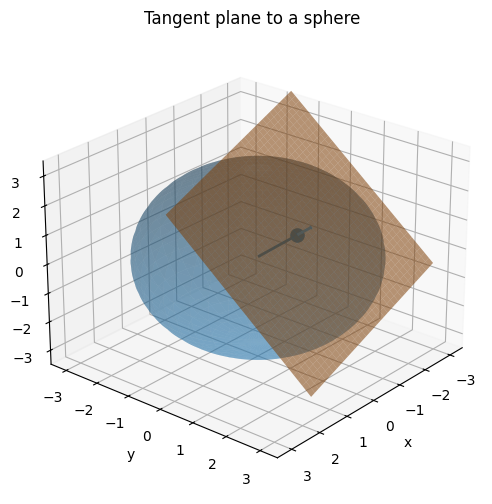

In [20]:
def sphere(radius=3, n_u=120, n_v=60):
    u = np.linspace(0, 2*np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)
    U, V = np.meshgrid(u, v)
    X = radius*np.cos(U)*np.sin(V)
    Y = radius*np.sin(U)*np.sin(V)
    Z = radius*np.cos(V)
    return X, Y, Z

X_s, Y_s, Z_s = sphere(radius=3)

x_plane = np.linspace(-1.2, 3.2, 35)
y_plane = np.linspace(0.0, 4.2, 35)
Xp, Yp = np.meshgrid(x_plane, y_plane)
Zp = P[2] - (normal[0]*(Xp - P[0]) + normal[1]*(Yp - P[1])) / normal[2]

fig, ax = make_3d_axes(title="Tangent plane to a sphere", elev=25, azim=40)
ax.plot_surface(X_s, Y_s, Z_s, alpha=0.35, linewidth=0)
ax.plot_surface(Xp, Yp, Zp, alpha=0.55, linewidth=0)
ax.scatter([P[0]], [P[1]], [P[2]], s=90)
ax.quiver(0, 0, 0, P[0], P[1], P[2], arrow_length_ratio=0.1, linewidth=2)
ax.quiver(P[0], P[1], P[2],
          normal[0]/norm(normal), normal[1]/norm(normal), normal[2]/norm(normal),
          arrow_length_ratio=0.1, linewidth=2)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_zlim(-3.5, 3.5)
plt.show()

## 19. Tangent plane to an ellipsoid

Consider the ellipsoid

$$
F(x,y,z)=\frac{x^2}{4}+\frac{y^2}{9}+z^2=1.
$$

At a point $P=(x_0,y_0,z_0)$ on the ellipsoid,

$$
\nabla F(P)=\left\langle \frac{x_0}{2},\frac{2y_0}{9},2z_0\right\rangle.
$$

In [21]:
def F_ellipsoid_grad(P):
    x0, y0, z0 = P
    return np.array([x0/2, 2*y0/9, 2*z0], dtype=float)

P_ell = np.array([1.0, 1.5, np.sqrt(1 - 1**2/4 - 1.5**2/9)])
n_ell = F_ellipsoid_grad(P_ell)

print("Point on ellipsoid:", P_ell)
print("Check F(P):", P_ell[0]**2/4 + P_ell[1]**2/9 + P_ell[2]**2)
print("Normal vector:", n_ell)

Point on ellipsoid: [1.       1.5      0.707107]
Check F(P): 1.0
Normal vector: [0.5      0.333333 1.414214]


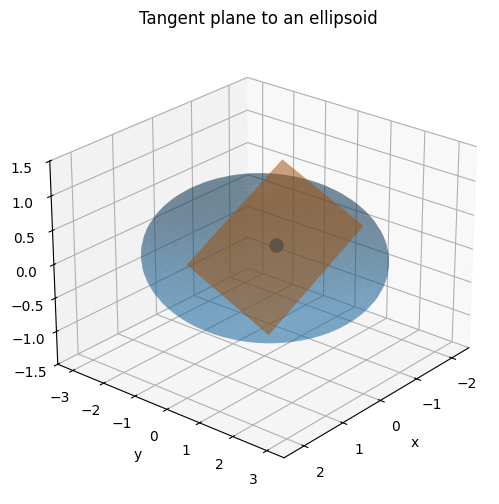

In [22]:
u = np.linspace(0, 2*np.pi, 120)
v = np.linspace(0, np.pi, 60)
U, V = np.meshgrid(u, v)
Xell = 2*np.cos(U)*np.sin(V)
Yell = 3*np.sin(U)*np.sin(V)
Zell = np.cos(V)

x_plane = np.linspace(P_ell[0] - 1.2, P_ell[0] + 1.2, 35)
y_plane = np.linspace(P_ell[1] - 1.2, P_ell[1] + 1.2, 35)
Xp, Yp = np.meshgrid(x_plane, y_plane)
Zp = P_ell[2] - (n_ell[0]*(Xp - P_ell[0]) + n_ell[1]*(Yp - P_ell[1])) / n_ell[2]

fig, ax = make_3d_axes(title="Tangent plane to an ellipsoid", elev=25, azim=40)
ax.plot_surface(Xell, Yell, Zell, alpha=0.35, linewidth=0)
ax.plot_surface(Xp, Yp, Zp, alpha=0.55, linewidth=0)
ax.scatter([P_ell[0]], [P_ell[1]], [P_ell[2]], s=90)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-3.5, 3.5)
ax.set_zlim(-1.5, 1.5)
plt.show()

---

# Part VII. Differentiability and failure of local linearity

Having partial derivatives at a point does not always guarantee a good tangent plane.

A classic warning example is

$$
f(x,y)=
\begin{cases}
\dfrac{xy}{\sqrt{x^2+y^2}}, & (x,y)\ne(0,0),\\
0, & (x,y)=(0,0).
\end{cases}
$$

At the origin, both partial derivatives are $0$, so the candidate linearization is $L(x,y)=0$.  
But along $y=x$, the function behaves like $|x|/\sqrt2$, which is not small compared with distance to the origin.

## 20. Visualizing failure of local linearity

/tmp/ipykernel_10372/3405842925.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return np.where(R == 0, 0, X*Y/R)


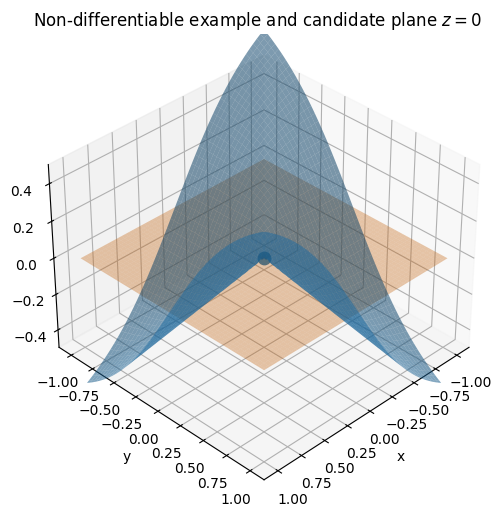

(array([[-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        ...,
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ]], shape=(100, 100)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.979798, -0.979798, -0.979798, ..., -0.979798, -0.979798,
         -0.979798],
        [-0.959596, -0.959596, -0.959596, ..., -0.959596, -0.959596,
         -0.959596],
        ...,
        [ 0.959596,  0.959596,  0.959596, ...,  0.959596,  0.959596,
          0.959596],
        [ 0.979798,  0.979798,  0.979798, ...,  0.9797

In [23]:
def f_not_diff(X, Y):
    R = np.sqrt(X**2 + Y**2)
    return np.where(R == 0, 0, X*Y/R)

L_zero = lambda X, Y: 0*X

plot_surface_and_plane(
    f_not_diff, L_zero, 0, 0,
    xmin=-1, xmax=1, ymin=-1, ymax=1,
    title=r"Non-differentiable example and candidate plane $z=0$",
    zlim=(-0.5, 0.5),
    elev=35,
    azim=45
)

## 21. Error ratio test

For differentiability at the origin with candidate $L=0$, we need

$$
\frac{|f(x,y)-0|}{\sqrt{x^2+y^2}}\to0.
$$

We sample this ratio on circles centered at the origin.

In [24]:
theta = np.linspace(0, 2*np.pi, 720, endpoint=False)
radii = np.array([0.5, 0.25, 0.125, 0.0625, 0.03125])

for r in radii:
    Xc = r*np.cos(theta)
    Yc = r*np.sin(theta)
    ratio = np.abs(f_not_diff(Xc, Yc)) / r
    print(f"r={r:.5f}, max ratio={np.max(ratio):.6f}, mean ratio={np.mean(ratio):.6f}")

r=0.50000, max ratio=0.500000, mean ratio=0.318302
r=0.25000, max ratio=0.500000, mean ratio=0.318302
r=0.12500, max ratio=0.500000, mean ratio=0.318302
r=0.06250, max ratio=0.500000, mean ratio=0.318302
r=0.03125, max ratio=0.500000, mean ratio=0.318302


The maximum ratio does not approach $0$.  
This indicates that the candidate tangent plane is not a valid local linear approximation.

---

# Part VIII. Local linear models in optimization

Linear approximation is the first local model behind gradient-based optimization.

For a loss function $J(\theta_0,\theta_1)$, near a point $\theta$,

$$
J(\theta+\Delta\theta)\approx J(\theta)+\nabla J(\theta)\cdot\Delta\theta.
$$

The negative gradient direction makes this linear model decrease fastest.

## 22. Least-squares loss landscape

We fit a line

$$
\widehat y=\beta_0+\beta_1x.
$$

The loss is

$$
J(\beta_0,\beta_1)=\sum_i (y_i-\beta_0-\beta_1x_i)^2.
$$

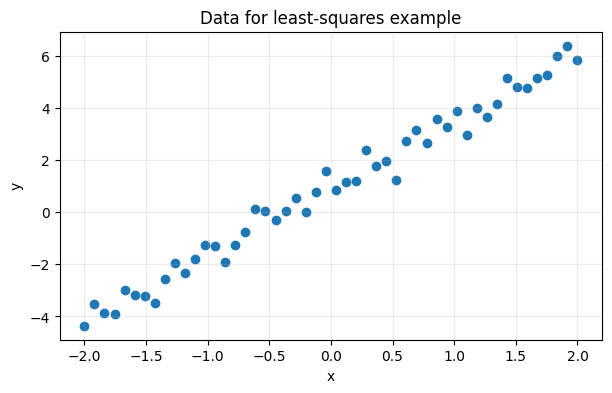

In [25]:
rng = np.random.default_rng(909)

x_data = np.linspace(-2, 2, 50)
y_data = 1.0 + 2.5*x_data + rng.normal(scale=0.45, size=x_data.shape)

def ls_loss(beta0, beta1):
    pred = beta0 + beta1*x_data
    return np.sum((y_data - pred)**2)

def ls_grad(beta0, beta1):
    residuals = y_data - (beta0 + beta1*x_data)
    d0 = -2*np.sum(residuals)
    d1 = -2*np.sum(x_data*residuals)
    return np.array([d0, d1], dtype=float)

plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_data)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data for least-squares example")
plt.grid(True, alpha=0.25)
plt.show()

## 23. Linearization of the loss at a parameter point

In [26]:
theta0 = np.array([0.0, 0.0])
J0 = ls_loss(theta0[0], theta0[1])
grad0 = ls_grad(theta0[0], theta0[1])

def J_linearized(B0, B1):
    return J0 + grad0[0]*(B0 - theta0[0]) + grad0[1]*(B1 - theta0[1])

print("theta0:", theta0)
print("J(theta0):", J0)
print("grad J(theta0):", grad0)
print("Unit negative gradient direction:", -unit(grad0))

theta0: [0. 0.]
J(theta0): 508.20941600752803
grad J(theta0): [ -94.488454 -355.606364]
Unit negative gradient direction: [0.2568   0.966465]


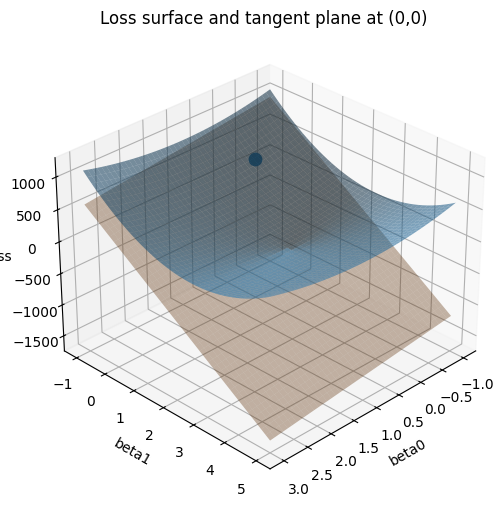

In [27]:
b0_grid = np.linspace(-1, 3, 130)
b1_grid = np.linspace(-1, 5, 130)
B0, B1 = np.meshgrid(b0_grid, b1_grid)

J = np.zeros_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        J[i,j] = ls_loss(B0[i,j], B1[i,j])

Jlin = J_linearized(B0, B1)

fig, ax = make_3d_axes(title="Loss surface and tangent plane at (0,0)", elev=30, azim=45)
ax.plot_surface(B0, B1, J, linewidth=0, alpha=0.55)
ax.plot_surface(B0, B1, Jlin, linewidth=0, alpha=0.35)
ax.scatter([theta0[0]], [theta0[1]], [J0], s=80)
ax.set_xlabel("beta0")
ax.set_ylabel("beta1")
ax.set_zlabel("loss")
plt.show()

## 24. The linear model predicts descent

Small steps in the negative gradient direction should decrease the loss.

In [28]:
direction = -unit(grad0)
step_sizes = np.array([0.001, 0.005, 0.01, 0.02, 0.05])

print(f"{'step':>10s} {'true change':>14s} {'linear change':>16s}")
for s in step_sizes:
    theta_new = theta0 + s*direction
    true_change = ls_loss(theta_new[0], theta_new[1]) - J0
    linear_change = np.dot(grad0, s*direction)
    print(f"{s:10.4f} {true_change:14.6f} {linear_change:16.6f}")

      step    true change    linear change
    0.0010      -0.367877        -0.367946
    0.0050      -1.838025        -1.839728
    0.0100      -3.672645        -3.679456
    0.0200      -7.331668        -7.358912
    0.0500     -18.227006       -18.397279


---

# Part IX. Chapter mini-project: local terrain modeling

A hiker is standing on a terrain surface

$$
z=h(x,y).
$$

A tangent plane provides a local flat-earth approximation to the terrain near the hiker.

## 25. Define a terrain surface

In [29]:
def terrain(X, Y):
    hill1 = 2.0*np.exp(-0.5*((X - 1.2)**2 + (Y + 0.5)**2))
    hill2 = 1.3*np.exp(-0.8*((X + 1.5)**2 + (Y - 1.0)**2))
    valley = -1.2*np.exp(-0.7*((X - 0.2)**2 + (Y - 1.8)**2))
    waves = 0.25*np.sin(2*X)*np.cos(1.5*Y)
    return hill1 + hill2 + valley + waves

a_t, b_t = 0.8, -0.6
grad_t = finite_gradient(terrain, a_t, b_t)

def L_terrain(X, Y):
    return terrain(a_t, b_t) + grad_t[0]*(X - a_t) + grad_t[1]*(Y - b_t)

print("Hiker position:", (a_t, b_t))
print("Height:", terrain(a_t, b_t))
print("Estimated gradient:", grad_t)
print("Local uphill unit direction:", unit(grad_t))

Hiker position: (0.8, -0.6)
Height: 1.9782513360548029
Estimated gradient: [0.73067  0.427969]
Local uphill unit direction: [0.862881 0.505407]


## 26. Terrain and local tangent plane

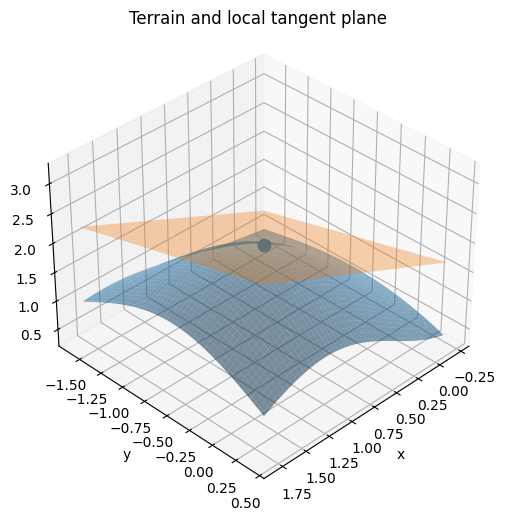

(array([[-0.2     , -0.179798, -0.159596, ...,  1.759596,  1.779798,
          1.8     ],
        [-0.2     , -0.179798, -0.159596, ...,  1.759596,  1.779798,
          1.8     ],
        [-0.2     , -0.179798, -0.159596, ...,  1.759596,  1.779798,
          1.8     ],
        ...,
        [-0.2     , -0.179798, -0.159596, ...,  1.759596,  1.779798,
          1.8     ],
        [-0.2     , -0.179798, -0.159596, ...,  1.759596,  1.779798,
          1.8     ],
        [-0.2     , -0.179798, -0.159596, ...,  1.759596,  1.779798,
          1.8     ]], shape=(100, 100)),
 array([[-1.6     , -1.6     , -1.6     , ..., -1.6     , -1.6     ,
         -1.6     ],
        [-1.579798, -1.579798, -1.579798, ..., -1.579798, -1.579798,
         -1.579798],
        [-1.559596, -1.559596, -1.559596, ..., -1.559596, -1.559596,
         -1.559596],
        ...,
        [ 0.359596,  0.359596,  0.359596, ...,  0.359596,  0.359596,
          0.359596],
        [ 0.379798,  0.379798,  0.379798, ...,  0.3797

In [30]:
plot_surface_and_plane(
    terrain, L_terrain, a_t, b_t,
    xmin=-0.2, xmax=1.8, ymin=-1.6, ymax=0.4,
    title="Terrain and local tangent plane",
    elev=35,
    azim=45
)

## 27. Terrain contours and local model directions

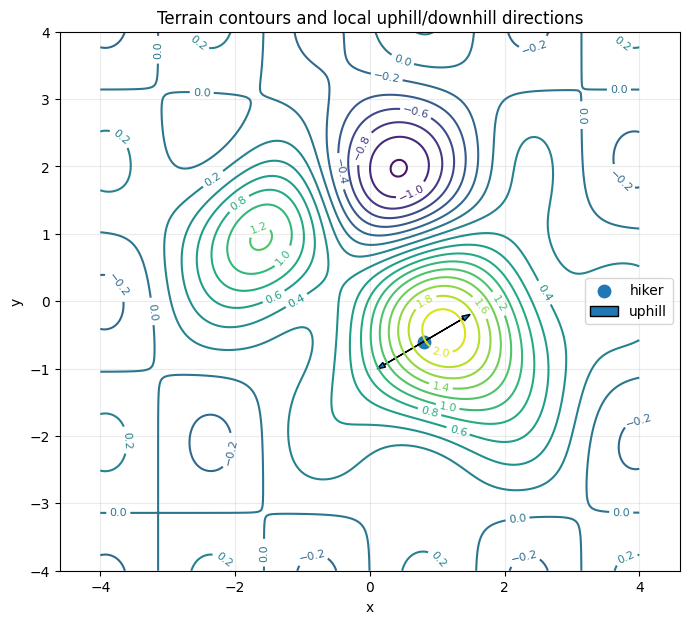

In [31]:
x, y, X, Y = make_grid(-4, 4, -4, 4, n=240)
Z = terrain(X, Y)

plt.figure(figsize=(8, 7))
cs = plt.contour(X, Y, Z, levels=18)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([a_t], [b_t], s=80, label="hiker")
g = grad_t
plt.arrow(a_t, b_t, 0.8*unit(g)[0], 0.8*unit(g)[1],
          head_width=0.08, length_includes_head=True, label="uphill")
plt.arrow(a_t, b_t, -0.8*unit(g)[0], -0.8*unit(g)[1],
          head_width=0.08, length_includes_head=True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain contours and local uphill/downhill directions")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 28. Accuracy of the terrain tangent plane

    radius      max error     mean error
     0.020     0.00047108     0.00044431
     0.050     0.00295695     0.00277546
     0.100     0.01190655     0.01108041
     0.200     0.04819420     0.04398094
     0.400     0.19734353     0.17059328
     0.800     0.81043054     0.60434384


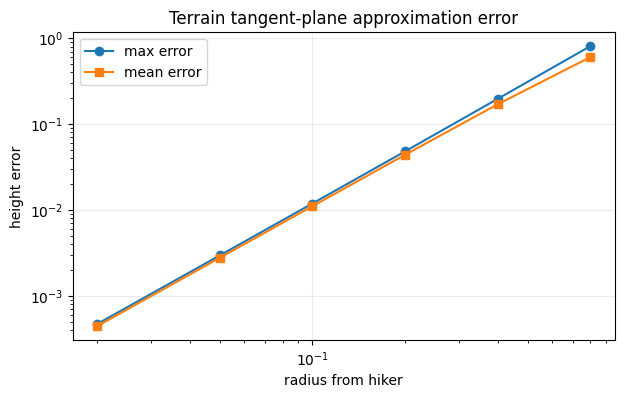

In [32]:
radii = np.array([0.02, 0.05, 0.10, 0.20, 0.40, 0.80])
max_err, mean_err = max_error_on_circle(terrain, L_terrain, a_t, b_t, radii)

print(f"{'radius':>10s} {'max error':>14s} {'mean error':>14s}")
for r, me, ave in zip(radii, max_err, mean_err):
    print(f"{r:10.3f} {me:14.8f} {ave:14.8f}")

plt.figure(figsize=(7, 4))
plt.loglog(radii, max_err, marker="o", label="max error")
plt.loglog(radii, mean_err, marker="s", label="mean error")
plt.xlabel("radius from hiker")
plt.ylabel("height error")
plt.title("Terrain tangent-plane approximation error")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 29. Mini-project questions

Answer the following in a markdown cell:

1. What is the tangent plane to the terrain at the hiker's location?
2. In which direction should the hiker walk to increase elevation most rapidly?
3. In which direction should the hiker walk to keep elevation approximately constant?
4. How far from the hiker does the tangent-plane model remain accurate?
5. Why is a tangent plane a local model rather than a global model?

In [33]:
print("Tangent plane model:")
print("z ≈ h0 + gx(x-a) + gy(y-b)")
print("h0 =", terrain(a_t, b_t))
print("gx =", grad_t[0])
print("gy =", grad_t[1])
print("a =", a_t)
print("b =", b_t)

level_direction = np.array([grad_t[1], -grad_t[0]])
print("\nApproximate level-walking unit directions:")
print(unit(level_direction), "and", -unit(level_direction))

Tangent plane model:
z ≈ h0 + gx(x-a) + gy(y-b)
h0 = 1.9782513360548029
gx = 0.7306698232234509
gy = 0.4279686670716209
a = 0.8
b = -0.6

Approximate level-walking unit directions:
[ 0.505407 -0.862881] and [-0.505407  0.862881]


---

# Part X. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Linearization

Let

$$
f(x,y)=\sqrt{x^2+y^2+1}.
$$

Find the linearization at $(1,2)$ and use it to estimate $f(1.02,1.97)$.

In [34]:
# Exercise A workspace

def exercise_A_f(X, Y):
    return np.sqrt(X**2 + Y**2 + 1)

# Your code here

### Reference solution for Exercise A

In [35]:
def exercise_A_fx(X, Y):
    return X / np.sqrt(X**2 + Y**2 + 1)

def exercise_A_fy(X, Y):
    return Y / np.sqrt(X**2 + Y**2 + 1)

aA, bA = 1.0, 2.0
L_A = linearization(exercise_A_f, exercise_A_fx, exercise_A_fy, aA, bA)

x0, y0 = 1.02, 1.97
print("f(a,b):", exercise_A_f(aA, bA))
print("f_x(a,b):", exercise_A_fx(aA, bA))
print("f_y(a,b):", exercise_A_fy(aA, bA))
print("Linear estimate:", L_A(x0, y0))
print("True value:", exercise_A_f(x0, y0))
print("Error:", L_A(x0, y0) - exercise_A_f(x0, y0))

f(a,b): 2.449489742783178
f_x(a,b): 0.4082482904638631
f_y(a,b): 0.8164965809277261
Linear estimate: 2.4331598111646233
True value: 2.4333721458091855
Error: -0.0002123346445621621


## Exercise B. Tangent plane to a graph

Let

$$
f(x,y)=\sin x+\cos y.
$$

Find the tangent plane at $(0,0)$ and plot the surface with the tangent plane.

In [36]:
# Exercise B workspace

def exercise_B_f(X, Y):
    return np.sin(X) + np.cos(Y)

# Your code here

### Reference solution for Exercise B

Tangent plane:
z = 1 + x


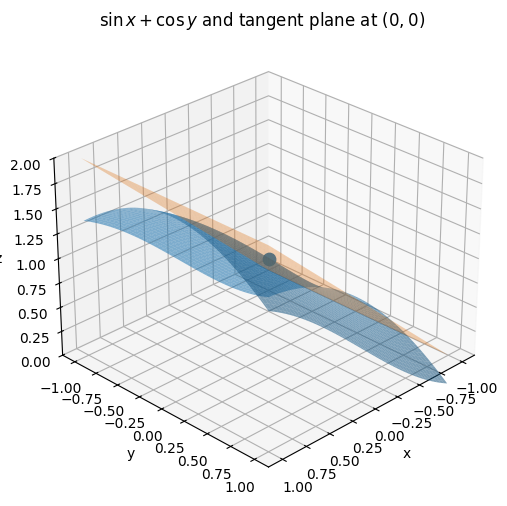

(array([[-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        ...,
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ],
        [-1.      , -0.979798, -0.959596, ...,  0.959596,  0.979798,
          1.      ]], shape=(100, 100)),
 array([[-1.      , -1.      , -1.      , ..., -1.      , -1.      ,
         -1.      ],
        [-0.979798, -0.979798, -0.979798, ..., -0.979798, -0.979798,
         -0.979798],
        [-0.959596, -0.959596, -0.959596, ..., -0.959596, -0.959596,
         -0.959596],
        ...,
        [ 0.959596,  0.959596,  0.959596, ...,  0.959596,  0.959596,
          0.959596],
        [ 0.979798,  0.979798,  0.979798, ...,  0.9797

In [37]:
def exercise_B_fx(X, Y):
    return np.cos(X)

def exercise_B_fy(X, Y):
    return -np.sin(Y)

aB, bB = 0.0, 0.0
L_B = linearization(exercise_B_f, exercise_B_fx, exercise_B_fy, aB, bB)

print("Tangent plane:")
print("z = 1 + x")

plot_surface_and_plane(
    exercise_B_f, L_B, aB, bB,
    xmin=-1, xmax=1, ymin=-1, ymax=1,
    title=r"$\sin x+\cos y$ and tangent plane at $(0,0)$",
    zlim=(0, 2)
)

## Exercise C. Differentials

Use differentials to estimate the change in

$$
z=x^2e^y
$$

when $(x,y)$ changes from $(2,0)$ to $(2.01,-0.03)$.

In [38]:
# Exercise C workspace

def exercise_C_f(X, Y):
    return X**2 * np.exp(Y)

# Your code here

### Reference solution for Exercise C

In [39]:
def exercise_C_fx(X, Y):
    return 2*X*np.exp(Y)

def exercise_C_fy(X, Y):
    return X**2*np.exp(Y)

aC, bC = 2.0, 0.0
dx, dy = 0.01, -0.03

true_delta = exercise_C_f(aC + dx, bC + dy) - exercise_C_f(aC, bC)
dz = exercise_C_fx(aC, bC)*dx + exercise_C_fy(aC, bC)*dy

print("True change Delta z:", true_delta)
print("Differential estimate dz:", dz)
print("Error:", dz - true_delta)

True change Delta z: -0.07930299991067313
Differential estimate dz: -0.07999999999999999
Error: -0.0006970000893268546


## Exercise D. Tangent plane to a level surface

Find the tangent plane to

$$
x^2+2y^2+3z^2=6
$$

at $(1,1,1)$.

In [40]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [41]:
P = np.array([1.0, 1.0, 1.0])
normal = np.array([2*P[0], 4*P[1], 6*P[2]])

print("Normal vector:", normal)
print("Tangent plane:")
print("2(x-1)+4(y-1)+6(z-1)=0")
print("Equivalent: 2x+4y+6z=12")

Normal vector: [2. 4. 6.]
Tangent plane:
2(x-1)+4(y-1)+6(z-1)=0
Equivalent: 2x+4y+6z=12


## Exercise E. Error order

For

$$
f(x,y)=e^{x+y},
$$

compare the maximum linearization error on circles of radius $r$ around $(0,0)$.

In [42]:
# Exercise E workspace

def exercise_E_f(X, Y):
    return np.exp(X + Y)

# Your code here

### Reference solution for Exercise E

r=0.010, max error=1.00473076e-04
r=0.020, max error=4.03798054e-04
r=0.040, max error=1.63060143e-03
r=0.080, max error=6.64834321e-03
r=0.160, max error=2.76452352e-02
r=0.320, max error=1.19765535e-01


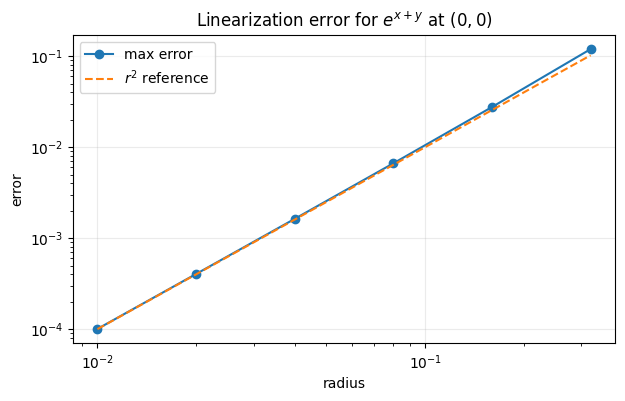

In [43]:
def exercise_E_fx(X, Y):
    return np.exp(X + Y)

def exercise_E_fy(X, Y):
    return np.exp(X + Y)

aE, bE = 0.0, 0.0
L_E = linearization(exercise_E_f, exercise_E_fx, exercise_E_fy, aE, bE)

radii = np.array([0.01, 0.02, 0.04, 0.08, 0.16, 0.32])
max_err, mean_err = max_error_on_circle(exercise_E_f, L_E, aE, bE, radii)

for r, me in zip(radii, max_err):
    print(f"r={r:.3f}, max error={me:.8e}")

plt.figure(figsize=(7, 4))
plt.loglog(radii, max_err, marker="o", label="max error")
plt.loglog(radii, radii**2, linestyle="--", label=r"$r^2$ reference")
plt.xlabel("radius")
plt.ylabel("error")
plt.title(r"Linearization error for $e^{x+y}$ at $(0,0)$")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Formula summary

## Linearization

$$
L(x,y)=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b).
$$

## Tangent plane to a graph

For $z=f(x,y)$ at $(a,b,f(a,b))$,

$$
z=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b).
$$

## Differential

$$
dz=df=f_x(a,b)\,dx+f_y(a,b)\,dy.
$$

## Change versus differential

$$
\Delta z=f(a+dx,b+dy)-f(a,b),
\qquad
\Delta z\approx dz.
$$

## Tangent plane to a level surface

For $F(x,y,z)=c$ at $P=(a,b,c_0)$,

$$
\nabla F(P)\cdot\langle x-a,\;y-b,\;z-c_0\rangle=0.
$$

## Differentiability error condition

A differentiable function satisfies

$$
f(a+\Delta x,b+\Delta y)-L(a+\Delta x,b+\Delta y)
=o\left(\sqrt{(\Delta x)^2+(\Delta y)^2}\right).
$$

# End of Chapter 9 Lab

You have used Python to explore:

- local linear approximation,
- tangent planes to graphs,
- approximation error,
- differentials,
- measurement error propagation,
- tangent planes to level surfaces,
- differentiability as local linearity,
- and tangent-plane models in optimization and terrain analysis.

These ideas prepare for the total derivative, chain rule, implicit differentiation, optimization, and multivariable Taylor polynomials.